<a href="https://colab.research.google.com/github/shachar-ug/FastSpeech2/blob/master/Age_classifier_wav2vec_trained.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[Notion data page](https://www.notion.so/uglabs/ALL-DATA-15f6bbab4afb804bba33f165dd821b34)

In [1]:
!pip install gcsfs transformers pandas cudf-cu12 scikit-learn wandb


In [2]:
from google.colab import userdata, auth
auth.authenticate_user()

In [3]:
#!wandb login

In [4]:
import os
import wandb

wandb_token = userdata.get('wb-token')
os.environ["WANDB_API_KEY"] = wandb_token

wandb.login() # Login to WandB (optional, but might help with resolving issues)

# Initialize WandB with project and entity, ensuring a new run
wandb.init(project="agenet", entity="shachar-ug", reinit=True)  # Replace with your actual values


wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: shachar-ug to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [5]:
# if False:
#   import gcsfs
#   import zipfile
#   import io
#   from pathlib import Path

#   # Setup
#   project_id = 'confident-totem-319006'
#   gcs_path = 'asr_datasets/raw/jibo_kids/combined.zip'
#   extract_dir = Path('data')
#   extract_dir.mkdir(parents=True, exist_ok=True)

#   # Init GCS and download ZIP
#   fs = gcsfs.GCSFileSystem(project=project_id)

#   with fs.open(gcs_path, 'rb') as f:
#       with zipfile.ZipFile(io.BytesIO(f.read())) as zip_ref:
#           zip_ref.extractall(extract_dir)

#   print(f"Extracted {gcs_path} into {extract_dir.resolve()}")

In [6]:
# # from transformers import AutoProcessor, AutoModelForAudioClassification

# # processor = AutoProcessor.from_pretrained("bookbot/wav2vec2-adult-child-cls")
# # model = AutoModelForAudioClassification.from_pretrained("bookbot/wav2vec2-adult-child-cls")

# # Use a pipeline as a high-level helper
# from transformers import pipeline

# pipe = pipeline("audio-classification", model="shacharu/wav2vec2-adult-child-cls")

In [7]:
# # Load model directly
# from transformers import AutoProcessor, AutoModelForAudioClassification

# processor = AutoProcessor.from_pretrained("bookbot/wav2vec2-adult-child-cls")
# model = AutoModelForAudioClassification.from_pretrained("bookbot/wav2vec2-adult-child-cls")


In [8]:
# from transformers import AutoFeatureExtractor, AutoModelForAudioClassification

# # Use AutoFeatureExtractor instead of AutoProcessor
# feature_extractor = AutoFeatureExtractor.from_pretrained("shacharu/wav2vec2-adult-child-cls")
# model = AutoModelForAudioClassification.from_pretrained("shacharu/wav2vec2-adult-child-cls")

In [9]:
# from transformers import AutoFeatureExtractor, AutoModelForAudioClassification, Wav2Vec2Model

# # Load the models
# feature_extractor_bookbot = AutoFeatureExtractor.from_pretrained("shacharu/wav2vec2-adult-child-cls")
# model_bookbot = AutoModelForAudioClassification.from_pretrained("shacharu/wav2vec2-adult-child-cls")
# feature_extractor_wav2vec2 = AutoFeatureExtractor.from_pretrained("facebook/wav2vec2-base-960h")
# model_wav2vec2 = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base-960h")

# # Get the underlying Wav2Vec2 model from the bookbot model
# wav2vec2_part_bookbot = model_bookbot.wav2vec2

# # Compare configurations (of the Wav2Vec2 parts)
# config_diff = wav2vec2_part_bookbot.config.to_dict() != model_wav2vec2.config.to_dict()

# # Compare architectures (number of parameters of the Wav2Vec2 parts)
# num_params_bookbot_wav2vec2 = sum(p.numel() for p in wav2vec2_part_bookbot.parameters())
# num_params_wav2vec2 = sum(p.numel() for p in model_wav2vec2.parameters())
# arch_diff = num_params_bookbot_wav2vec2 != num_params_wav2vec2

# # Print results
# print(f"Wav2Vec2 configurations are different: {config_diff}")
# print(f"Wav2Vec2 architectures are different: {arch_diff}")


# Download data

In [10]:
if False:
    from pathlib import Path
    import shutil  # Import shutil for directory removal

    def pull_github_repo(repo_url, local_path=None, branch=None):
        """
        Pull a GitHub repository using GitPython.

        Parameters:
        -----------
        repo_url : str
            URL of the GitHub repository to pull
        local_path : str, optional
            Local path where the repository should be cloned
            If None, uses the repository name as the local path
        branch : str, optional
            Specific branch to pull, if None, pulls the default branch

        Returns:
        --------
        str
            Path to the cloned repository
        """
        import os
        import git
        from git import Repo
        import re

        # Install gitpython if not already installed
        try:
            import git
        except ImportError:
            import sys
            import subprocess
            subprocess.check_call([sys.executable, "-m", "pip", "install", "gitpython"])
            import git

        # Extract repository name from URL if local_path is not specified
        if local_path is None:
            repo_name = re.search(r'/([^/]+?)(?:\.git)?$', repo_url).group(1)
            local_path = f"./{repo_name}"

        # Create directory if it doesn't exist
        os.makedirs(local_path, exist_ok=True)

        try:
            # Check if repo already exists
            if os.path.exists(os.path.join(local_path, '.git')):
                # If it exists, just pull the latest changes
                repo = Repo(local_path)
                origin = repo.remotes.origin

                if branch:
                    # Checkout and pull specific branch
                    repo.git.checkout(branch)
                    origin.pull(branch)
                    print(f"Pulled latest changes from branch '{branch}'.")
                else:
                    # Pull current branch
                    current_branch = repo.active_branch.name
                    origin.pull()
                    print(f"Pulled latest changes from branch '{current_branch}'.")

            else:
                # If it doesn't exist, clone it
                if branch:
                    # Clone specific branch, handling potential errors
                    try:
                        Repo.clone_from(repo_url, local_path, branch=branch)
                    except git.exc.GitCommandError as e:
                        print(f"Error cloning branch '{branch}': {e}")
                        return None

                    print(f"Repository cloned successfully to {local_path} (branch: {branch})")
                else:
                    # Clone default branch, handling potential errors
                    try:
                        Repo.clone_from(repo_url, local_path)
                    except git.exc.GitCommandError as e:
                        print(f"Error cloning default branch: {e}")
                        return None

                    print(f"Repository cloned successfully to {local_path}")

            # List contents
            print("\nContents of the repository:")
            import subprocess
            result = subprocess.run(['ls', '-la', local_path], capture_output=True, text=True)
            print(result.stdout)

            return local_path

        except git.exc.GitCommandError as e:
            print(f"An error occurred: {e}")
            return None


    # repo_path = pull_github_repo("https://github.com/balaji1312/Jibo_Kids.git")
    repo_path = pull_github_repo("https://github.com/uglabs/Jibo_Kids.git")

    Path("data").mkdir(parents=True, exist_ok=True)
    !git lfs install --skip-repo # skip repo configuration if already configured
    !cat ./Jibo_Kids/jibo_release_part_aa ./Jibo_Kids/jibo_release_part_ab > ./Jibo_Kids/combined.zip && unzip ./Jibo_Kids/combined.zip -d data/

    #shutil.rmtree('./Jibo_Kids', ignore_errors=True)



In [11]:
import gcsfs
import zipfile
import io
from pathlib import Path
from tqdm import tqdm

# Setup
project_id = 'confident-totem-319006'
gcs_path = 'asr_datasets/raw/jibo_kids/combined.zip'
extract_dir = Path('data')
extract_dir.mkdir(parents=True, exist_ok=True)

# Init GCS and get file size
fs = gcsfs.GCSFileSystem(project=project_id)
file_size = fs.info(gcs_path)['size']

# Download with progress bar
chunk_multiple = 64
buffer = io.BytesIO()
with fs.open(gcs_path, 'rb') as f:
    with tqdm(total=file_size, unit='B', unit_scale=True, desc='Downloading') as pbar:
        while True:
            chunk = f.read(chunk_multiple * 1024 * 1024)  # 1MB chunks
            if not chunk:
                break
            buffer.write(chunk)
            pbar.update(len(chunk))

# Extract ZIP
buffer.seek(0)
with zipfile.ZipFile(buffer) as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"Extracted {gcs_path} into {extract_dir.resolve()}")

Downloading: 100%|██████████| 2.74G/2.74G [03:01<00:00, 15.1MB/s]


Extracted asr_datasets/raw/jibo_kids/combined.zip into /content/data


# Model

In [13]:
import torch
from transformers import Wav2Vec2Processor, Wav2Vec2Model, AutoFeatureExtractor
from transformers import Wav2Vec2ForSequenceClassification
from torch.utils.data import Dataset, DataLoader
import torchaudio
from pathlib import Path
from typing import Optional, Callable, List, Dict, Tuple
import numpy as np
from torch.nn.utils.rnn import pad_sequence
import re
import multiprocessing

# Set multiprocessing start method to 'spawn' to avoid CUDA issues
# This must be done at the very beginning before creating any processes
if __name__ == "__main__":
    # Ensure multiprocessing uses 'spawn' method for CUDA compatibility
    multiprocessing.set_start_method('spawn', force=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

def extract_features(waveform, sample_rate):
    """Extracts features using the pre-loaded feature extractor and model."""
    inputs = feature_extractor(waveform, sampling_rate=sample_rate, return_tensors="pt").to(device)
    with torch.no_grad():
        last_hidden_state = model(**inputs).last_hidden_state
        # Average over the time dimension (dim=1)
        embeddings = last_hidden_state.mean(dim=1).cpu()

    return embeddings.cpu() # Move embeddings to CPU

def extract_batch_features(waveforms, sample_rate, max_length=None):
    """Extracts features for a batch of waveforms using the last hidden state."""

    inputs = feature_extractor(
        waveforms.squeeze(1).numpy(),  # Remove channel dimension
        sampling_rate=sample_rate,
        return_tensors="pt",
        padding=True,
        truncation=True if max_length is not None else False,
        max_length=max_length,
    ).to(device)

    with torch.no_grad():
        # Average over the time dimension (dim=1)
        embeddings = model(**inputs).last_hidden_state.mean(dim=1).cpu()

    del inputs
    return embeddings


age_labels = list(range(3, 8))
num_labels = len(age_labels)
label2id = {str(age): i for i, age in enumerate(age_labels)}  # {'3': 0, '4': 1, ...}
id2label = {i: str(age) for i, age in enumerate(age_labels)}  # {0: '3', 1: '4', ...}

feature_extractor = AutoFeatureExtractor.from_pretrained("shacharu/wav2vec2-adult-child-cls")
model = Wav2Vec2ForSequenceClassification.from_pretrained(
    "shacharu/wav2vec2-adult-child-cls",
    label2id=label2id,
    id2label=id2label,
    ignore_mismatched_sizes=True  # crucial for replacing the head

).to(device)

model.config.num_labels = num_labels
model.config.label2id = label2id
model.config.id2label = id2label

Using device: cuda


Some weights of Wav2Vec2ForSequenceClassification were not initialized from the model checkpoint at shacharu/wav2vec2-adult-child-cls and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([2]) in the checkpoint and torch.Size([5]) in the model instantiated
- classifier.weight: found shape torch.Size([2, 256]) in the checkpoint and torch.Size([5, 256]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [14]:
if False:
  from torch.utils.data import Dataset, DataLoader

  class BaseDataset(Dataset):
      def __init__(self, transform: Optional[Callable] = None):
          self.transform = transform
          self.samples: List[Dict] = []

      def __len__(self) -> int:
          return len(self.samples)

      def __getitem__(self, idx: int):
          raise NotImplementedError("Subclasses must implement this method.")


  class JiboDatasetV0(BaseDataset):
      def __init__(self, root_dir: str, sample_rate: int = 16000, transform: Optional[Callable] = None):
          super().__init__(transform)
          self.sample_rate = sample_rate
          self.files_to_skip = [
              'data/jibo_release/data/colors/T1027244/T1027244.wav',
              'data/jibo_release/data/blocks/T2037283/T2037283.wav'
          ]

          self._load_samples(Path(root_dir))
          print(f"Loaded {len(self.samples)} valid samples from {root_dir}")

          # Count samples by grade level
          grade_counts = {}
          for sample in self.samples:
              grade = sample['grade']
              if grade in grade_counts:
                  grade_counts[grade] += 1
              else:
                  grade_counts[grade] = 1

          print("Grade distribution:")
          for grade, count in sorted(grade_counts.items()):
              grade_name = {1: "Pre-kindergarten", 2: "Kindergarten", 3: "1st Grade"}.get(grade, f"Unknown ({grade})")
              print(f"  {grade_name}: {count} samples")

      def _extract_info_from_filename(self, wav_path: Path) -> Dict:
          """
          Extract demographic information from filename based on the JIBO Kids Corpus format:
          TXYY7ZZZ where:
          - X in {1,2} is the year of the study
          - YY in {01, 02, 03} is the child's year in school:
            - 01: Pre-kindergarten
            - 02: Kindergarten
            - 03: Grade 1
          - ZZZ is a unique identifier (odd for boys, even for girls)

          Returns a dictionary with extracted information.
          """
          # Get the filename without path and extension
          filename = wav_path.stem

          # Try to match the pattern in the filename
          pattern = r'T(\d)(\d{2})7(\d{3})'
          match = re.search(pattern, filename)

          if match:
              study_year = int(match.group(1))
              grade_code = int(match.group(2))
              child_id = int(match.group(3))

              # Determine grade level (1=Pre-K, 2=K, 3=1st Grade)
              if grade_code == 1:
                  grade = 1  # Pre-kindergarten
                  age = 3    # Approximate age
              elif grade_code == 2:
                  grade = 2  # Kindergarten
                  age = 5    # Approximate age
              elif grade_code == 3:
                  grade = 3  # 1st Grade
                  age = 7    # Approximate age
              else:
                  grade = 0  # Unknown
                  age = -1   # Unknown

              # Determine gender (odd=male, even=female)
              gender = 'male' if child_id % 2 == 1 else 'female'

              return {
                  'study_year': study_year,
                  'grade': grade,
                  'grade_code': grade_code,
                  'child_id': child_id,
                  'gender': gender,
                  'age': age  # Approximate age based on grade
                  'filename': filename
              }
          else:
              # If pattern doesn't match, return default values
              return {
                  'study_year': 0,
                  'grade': 0,
                  'grade_code': 0,
                  'child_id': 0,
                  'gender': 'unknown',
                  'age': -1
                  'filename':, filename
              }

      def _get_task_type(self, wav_path: Path) -> str:
          """
          Determine the task type based on the directory structure.
          """
          path_str = str(wav_path).lower()

          if 'letters_digits' in path_str:
              return 'letters_digits'
          elif 'brush' in path_str:
              return 'brush'
          elif 'colors' in path_str:
              return 'colors'
          elif 'blocks' in path_str:
              return 'blocks'
          else:
              return 'unknown'

      def _load_samples(self, root_path: Path):
          all_child_ids = set()
          for wav_path in root_path.rglob("*.wav"):
              if str(wav_path) in self.files_to_skip:
                  print(f"Skipping file: {wav_path}")
                  continue

              txt_path = wav_path.with_suffix(".txt")
              if not txt_path.exists():
                  print(f"Warning: Missing transcription for {wav_path}")
                  continue


              demo_info = self._extract_info_from_filename(wav_path)
              task_type = self._get_task_type(wav_path)
              self._parse_transcription(wav_path, txt_path, demo_info, task_type)
              all_child_ids.add(demo_info['child_id'])

      def _parse_transcription(self, wav_path: Path, txt_path: Path, demo_info: Dict, task_type: str):
          try:
              with txt_path.open("r") as f:
                  for line in f:
                      parts = line.strip().split("\t")
                      if len(parts) != 3:
                          continue

                      start, end, text = parts
                      start, end = float(start), float(end)

                      # Skip invalid duration segments
                      if end <= start or int((end - start) * self.sample_rate) <= 0:
                          continue

                      self.samples.append({
                          "audio_path": str(wav_path),
                          "start_time": start,
                          "end_time": end,
                          "text": text,
                          "age": demo_info['age'],
                          "grade": demo_info['grade'],
                          "gender": demo_info['gender'],
                          "task_type": task_type,
                          "child_id": demo_info['child_id']
                      })
          except Exception as e:
              print(f"Error processing {txt_path}: {e}")

      def __getitem__(self, idx: int) -> Tuple[torch.Tensor, int, str, torch.Tensor, int]:
          sample = self.samples[idx]
          audio_path = sample["audio_path"]
          start, end, text = sample["start_time"], sample["end_time"], sample["text"]
          age = sample["age"]

          # Error handling for audio file loading
          try:
              info = torchaudio.info(audio_path)
              sample_rate = info.sample_rate
              offset = int(start * sample_rate)
              frames = int((end - start) * sample_rate)

              # Guard against invalid frame counts
              if frames <= 0:
                  print(f"Warning: Invalid num_frames ({frames}) for {audio_path}, returning empty.")
                  return torch.empty(0), sample_rate, text, torch.zeros(1, 768), age  # Adjust embedding dimension if needed

              # Load and resample audio if needed
              waveform, sr = torchaudio.load(audio_path, frame_offset=offset, num_frames=frames)

              # Resample if needed
              if sr != self.sample_rate:
                  resampler = torchaudio.transforms.Resample(sr, self.sample_rate)
                  waveform = resampler(waveform)

              if self.transform:
                  waveform = self.transform(waveform)

              return waveform, self.sample_rate, text, age

          except Exception as e:
              print(f"Error processing sample {idx} ({audio_path}): {e}")
              # Return empty tensors in case of error
              return torch.empty(0), sample_rate, text, age  # Adjust embedding dimension if needed


  def collate_fn(batch):
      # Filter out empty waveforms
      batch = [item for item in batch if item[0].numel() > 0]

      # Handle empty batch (all samples were invalid)
      if not batch:
          # Return empty tensors with correct types for each component
          return (torch.empty(0, 1, 0),
                  torch.empty(0, 0, dtype=torch.long),
                  [],
                  [],
                  torch.empty(0, dtype=torch.long))

      waveforms, sample_rates, texts, ages = zip(*batch)

      # Convert waveforms for padding: (1, T_i) → make (T_i,)
      waveforms_for_pad = [w.squeeze(0) for w in waveforms]

      # Pad to the longest sequence in the batch
      padded_waveforms = pad_sequence(waveforms_for_pad, batch_first=True)

      # Create attention mask: 1 where there's data, 0 for padding
      lengths = [w.shape[1] for w in waveforms]  # Get original lengths
      max_len = padded_waveforms.shape[1]
      attention_mask = torch.zeros((len(waveforms), max_len), dtype=torch.long)
      for i, length in enumerate(lengths):
          attention_mask[i, :length] = 1

      # Add channel dim back: (B, T) -> (B, 1, T)
      padded_waveforms = padded_waveforms.unsqueeze(1)

      # Convert ages to a tensor
      ages = torch.tensor(ages, dtype=torch.long)

      return padded_waveforms, attention_mask, sample_rates, texts, ages




  # root_dir = 'data/jibo_release/data'

  # Create dataset
  # dataset = JiboDataset(root_dir)


  if False:
    # Create dataloader with batch size and GPU acceleration using the collate_fn
    # Important: set num_workers=0 to avoid CUDA multiprocessing issues
    dataloader = DataLoader(
        dataset,
        batch_size=16,
        shuffle=True,
        collate_fn=collate_fn,
        num_workers=0,     # Set to 0 to avoid CUDA multiprocessing issues
        pin_memory=True    # Speed up host to GPU transfers
    )

    # Process a batch
    for batch_idx, batch in enumerate(dataloader):
        waveforms, attention_masks, sample_rates, texts, ages = batch

        # Skip empty batches
        if waveforms.numel() == 0:
            print(f"Batch {batch_idx}: Empty batch, skipping")
            continue

        print(f"Batch {batch_idx}: {len(waveforms)} samples")
        print(f"Waveform shape: {waveforms.shape}")
        print(f"Attention mask shape: {attention_masks.shape}")
        print(f"Ages: {ages}")

        # If you're using these for training, you would now:
        # 1. Move the inputs to device
        waveforms = waveforms.to(device)
        attention_masks = attention_masks.to(device)
        ages = ages.to(device)

        # 2. Example forward pass for age prediction model
        # outputs = age_prediction_model(waveforms, attention_mask=attention_masks)
        # loss = loss_fn(outputs, ages)

        # Only process a few batches for testing
        if batch_idx >= 2:
            break



In [39]:
import random

class JiboDataset(Dataset):
    def __init__(self, root_dir: str, sample_rate: int = 16000, transform: Optional[Callable] = None, train_ratio=0.8, val_ratio=0.1, test_ratio=0.1):
        super().__init__()
        self.transform = transform
        self.samples: List[Dict] = []
        self.sample_rate = sample_rate
        self.root_dir = root_dir
        self.files_to_skip = [
            'data/jibo_release/data/colors/T1027244/T1027244.wav',
            'data/jibo_release/data/blocks/T2037283/T2037283.wav'
        ]
        self.train_ratio = train_ratio
        self.val_ratio = val_ratio
        self.test_ratio = test_ratio

        self._load_samples(Path(root_dir))
        print(f"Loaded {len(self.samples)} valid samples from {root_dir}")

        # Count samples by grade level
        grade_counts = {}
        for sample in self.samples:
            grade = sample['grade']
            if grade in grade_counts:
                grade_counts[grade] += 1
            else:
                grade_counts[grade] = 1

        print("Grade distribution:")
        for grade, count in sorted(grade_counts.items()):
            grade_name = {1: "Pre-kindergarten", 2: "Kindergarten", 3: "1st Grade"}.get(grade, f"Unknown ({grade})")
            print(f"  {grade_name}: {count} samples")

        # Initialize split_datasets
        self.split_datasets = self._create_split_datasets()

    def _extract_info_from_filename(self, wav_path: Path) -> Dict:
        """
        Extract demographic information from filename based on the JIBO Kids Corpus format:
        TXYY7ZZZ where:
        - X in {1,2} is the year of the study
        - YY in {01, 02, 03} is the child's year in school:
          - 01: Pre-kindergarten
          - 02: Kindergarten
          - 03: Grade 1
        - ZZZ is a unique identifier (odd for boys, even for girls)

        Returns a dictionary with extracted information.
        """
        # Get the filename without path and extension
        filename = wav_path.stem

        # Try to match the pattern in the filename
        pattern = r'T(\d)(\d{2})7(\d{3})'
        match = re.search(pattern, filename)

        if match:
            study_year = int(match.group(1))
            grade_code = int(match.group(2))
            child_id = int(match.group(3))

            # Determine grade level (1=Pre-K, 2=K, 3=1st Grade)
            if grade_code == 1:
                grade = 1  # Pre-kindergarten
                age = 3  # Approximate age
            elif grade_code == 2:
                grade = 2  # Kindergarten
                age = 5  # Approximate age
            elif grade_code == 3:
                grade = 3  # 1st Grade
                age = 7  # Approximate age
            else:
                grade = 0  # Unknown
                age = -1  # Unknown

            # Determine gender (odd=male, even=female)
            gender = 'male' if child_id % 2 == 1 else 'female'

            return {
                'study_year': study_year,
                'grade': grade,
                'grade_code': grade_code,
                'child_id': child_id,
                'gender': gender,
                'age': age  # Approximate age based on grade
            }
        else:
            # If pattern doesn't match, return default values
            return {
                'study_year': 0,
                'grade': 0,
                'grade_code': 0,
                'child_id': 0,
                'gender': 'unknown',
                'age': -1
            }

    def _get_task_type(self, wav_path: Path) -> str:
        """
        Determine the task type based on the directory structure.
        """
        path_str = str(wav_path).lower()

        if 'letters_digits' in path_str:
            return 'letters_digits'
        elif 'brush' in path_str:
            return 'brush'
        elif 'colors' in path_str:
            return 'colors'
        elif 'blocks' in path_str:
            return 'blocks'
        else:
            return 'unknown'

    def _load_samples(self, root_path: Path):
        for wav_path in root_path.rglob("*.wav"):
            if str(wav_path) in self.files_to_skip:
                print(f"Skipping file: {wav_path}")
                continue

            txt_path = wav_path.with_suffix(".txt")
            if not txt_path.exists():
                print(f"Warning: Missing transcription for {wav_path}")
                continue

            demo_info = self._extract_info_from_filename(wav_path)
            task_type = self._get_task_type(wav_path)
            self._parse_transcription(wav_path, txt_path, demo_info, task_type)

    def _parse_transcription(self, wav_path: Path, txt_path: Path, demo_info: Dict, task_type: str):
        try:
            with txt_path.open("r") as f:
                for line in f:
                    parts = line.strip().split("\t")
                    if len(parts) != 3:
                        continue

                    start, end, text = parts
                    start, end = float(start), float(end)

                    # Skip invalid duration segments
                    if end <= start or int((end - start) * self.sample_rate) <= 0:
                        continue

                    self.samples.append({
                        "audio_path": str(wav_path),
                        "start_time": start,
                        "end_time": end,
                        "text": text,
                        "age": demo_info['age'],
                        "grade": demo_info['grade'],
                        "gender": demo_info['gender'],
                        "task_type": task_type,
                        "child_id": demo_info['child_id']
                    })
        except Exception as e:
            print(f"Error processing {txt_path}: {e}")

    def _create_split_datasets(self):
        """Creates train/val/test splits with balanced age distribution and unique speaker IDs per split."""

        # Group samples by child ID
        child_id_groups = {}
        for sample in self.samples:
            child_id = sample["child_id"]
            if child_id not in child_id_groups:
                child_id_groups[child_id] = []
            child_id_groups[child_id].append(sample)

        # Shuffle child IDs to randomize the split
        all_child_ids = list(child_id_groups.keys())
        random.shuffle(all_child_ids)

        # Calculate split boundaries
        num_train = int(len(all_child_ids) * self.train_ratio)
        num_val = int(len(all_child_ids) * self.val_ratio)

        # Assign child IDs to splits
        train_child_ids = all_child_ids[:num_train]
        val_child_ids = all_child_ids[num_train:num_train + num_val]
        test_child_ids = all_child_ids[num_train + num_val:]

        # Create split datasets
        split_datasets = {"train": [], "val": [], "test": []}
        for child_id, samples in child_id_groups.items():
            if child_id in train_child_ids:
                split_datasets["train"].extend(samples)
            elif child_id in val_child_ids:
                split_datasets["val"].extend(samples)
            else:
                split_datasets["test"].extend(samples)

        return split_datasets

    def get_split_dataset(self, split: str):
        """Returns a new JiboDataset instance containing only samples from the specified split."""
        filtered_samples = self.split_datasets[split]
        new_dataset = JiboDataset(root_dir=self.root_dir, sample_rate=self.sample_rate, transform=self.transform,
                                 train_ratio=self.train_ratio, val_ratio=self.val_ratio, test_ratio=self.test_ratio)
        new_dataset.samples = filtered_samples
        return new_dataset

    @property
    def info(self):
        """Provides information about the return values of the __getitem__ method."""
        return "The __getitem__ method returns a tuple containing: (waveform, sample_rate, text, age, child_id, filename)"  # Update info

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, idx: int):
        sample = self.samples[idx]
        audio_path = sample["audio_path"]
        start, end, text = sample["start_time"], sample["end_time"], sample["text"]
        age = sample["age"]
        child_id = sample['child_id']  # Add this line to get child_id
        filename = Path(audio_path).name  # Extract filename from audio_path

        try:
            info = torchaudio.info(audio_path)
            sample_rate = info.sample_rate
            offset = int(start * sample_rate)
            frames = int((end - start) * sample_rate)

            if frames <= 0:
                print(f"Warning: Invalid num_frames ({frames}) for {audio_path}, returning empty.")
                return torch.empty(0), sample_rate, text, age, child_id, filename

            waveform, sr = torchaudio.load(audio_path, frame_offset=offset, num_frames=frames)
            waveform = waveform / waveform.abs().max()

            if sr != self.sample_rate:
                resampler = torchaudio.transforms.Resample(sr, self.sample_rate)
                waveform = resampler(waveform)

            if self.transform:
                waveform = self.transform(waveform)

            return waveform, self.sample_rate, text, age, child_id, filename

        except Exception as e:
            print(f"Error processing sample {idx} ({audio_path}): {e}")
            return torch.empty(0), sample_rate, text, age, child_id, filename



In [40]:
from torch.utils.data import ConcatDataset

# Dataset 1: jibo
root_dir = 'data/jibo_release/data'
jibo_dataset = JiboDataset(root_dir)
train_jibo_dataset = jibo_dataset.get_split_dataset("train")
val_jibo_dataset = jibo_dataset.get_split_dataset("val")
test_jibo_dataset = jibo_dataset.get_split_dataset("test")


# Concat datasets
train_dataset = ConcatDataset([train_jibo_dataset])
val_dataset = ConcatDataset([val_jibo_dataset])
test_dataset = ConcatDataset([test_jibo_dataset])

# dataloader = DataLoader(
#     dataset,
#     batch_size=16,
#     shuffle=True,
#     collate_fn=collate_fn,
#     num_workers=0,     # Set to 0 to avoid CUDA multiprocessing issues
#     pin_memory=True    # Speed up host to GPU transfers
# )

len(train_dataset), len(val_jibo_dataset), len(test_jibo_dataset)


Skipping file: data/jibo_release/data/blocks/T2037283/T2037283.wav
Skipping file: data/jibo_release/data/colors/T1027244/T1027244.wav
Loaded 8448 valid samples from data/jibo_release/data
Grade distribution:
  Pre-kindergarten: 1994 samples
  Kindergarten: 5143 samples
  1st Grade: 1311 samples
Skipping file: data/jibo_release/data/blocks/T2037283/T2037283.wav
Skipping file: data/jibo_release/data/colors/T1027244/T1027244.wav
Loaded 8448 valid samples from data/jibo_release/data
Grade distribution:
  Pre-kindergarten: 1994 samples
  Kindergarten: 5143 samples
  1st Grade: 1311 samples
Skipping file: data/jibo_release/data/blocks/T2037283/T2037283.wav
Skipping file: data/jibo_release/data/colors/T1027244/T1027244.wav
Loaded 8448 valid samples from data/jibo_release/data
Grade distribution:
  Pre-kindergarten: 1994 samples
  Kindergarten: 5143 samples
  1st Grade: 1311 samples
Skipping file: data/jibo_release/data/blocks/T2037283/T2037283.wav
Skipping file: data/jibo_release/data/colors/

(6667, 717, 1064)

In [42]:
import torchaudio
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import IPython.display as ipd

# Create the dataset
jibo_dataset = JiboDataset(root_dir='data/jibo_release/data')

audio_lengths = []
for i in tqdm(range(len(jibo_dataset)), desc="Processing audio files"):
    sample = jibo_dataset.samples[i]
    audio_path = sample["audio_path"]
    start_time = sample["start_time"]
    end_time = sample["end_time"]

    # Calculate segment length
    segment_length = end_time - start_time
    audio_lengths.append((i, segment_length))  # Store index and length

# Sort by segment length (ascending)
audio_lengths.sort(key=lambda item: item[1])


# # Create a histogram
# plt.hist(audio_lengths, bins=50)
# plt.xlabel("Audio Length (seconds)")
# plt.ylabel("Frequency")
# plt.title("Distribution of Audio Lengths in JiboDataset")
# plt.show()

# # Calculate some statistics
# avg_length = sum(audio_lengths) / len(audio_lengths)
# min_length = min(audio_lengths)
# max_length = max(audio_lengths)

# print(f"Average Audio Length: {avg_length:.2f} seconds")
# print(f"Minimum Audio Length: {min_length:.2f} seconds")
# print(f"Maximum Audio Length: {max_length:.2f} seconds")


Skipping file: data/jibo_release/data/blocks/T2037283/T2037283.wav
Skipping file: data/jibo_release/data/colors/T1027244/T1027244.wav
Loaded 8448 valid samples from data/jibo_release/data
Grade distribution:
  Pre-kindergarten: 1994 samples
  Kindergarten: 5143 samples
  1st Grade: 1311 samples


Processing audio files:   0%|          | 0/8448 [00:00<?, ?it/s]

In [44]:
import random
import IPython.display as ipd
import torchaudio

# Get shortest and longest segments
shortest_index, shortest_length = audio_lengths[0]

longest_index, longest_length = audio_lengths[-1]
waveform, sample_rate, text, age, child_id, filename = jibo_dataset[longest_index]
ipd.display(ipd.Audio(waveform.numpy(), rate=sample_rate))
text, child_id, filename

("I WILL TELL HIM TWO ONE PLUS TWO AND THEN THAT EQUALS THREE AND THEN THREE PLUS TWO EQUALS FIVE. AND THEN I THINK FIVE PLUS THAT FIVE MAKES TEN. SO THERE'S TEN CUBES.",
 275,
 'T2037275.wav')

In [33]:
import random
import IPython.display as ipd
import torchaudio

random_index = random.randint(0, len(jibo_dataset) - 1)
waveform, sample_rate, text, age, child_id = jibo_dataset[random_index]

# Play the audio
ipd.display(ipd.Audio(waveform.numpy(), rate=sample_rate))

# Print information about the sample
print(f"Text: {text}")
print(f"Age: {age}")
print(f"Child ID: {child_id}")

Text: I DON'T THINK SO.
Age: 3
Child ID: 245


In [17]:
print(train_jibo_dataset.info)
train_dataset[0]

The __getitem__ method returns a tuple containing: (waveform, sample_rate, text, age, child_id)


(tensor([[-0.0021, -0.0044, -0.0067,  ..., -0.0083, -0.0063, -0.0041]]),
 16000,
 'SIX.',
 5,
 281)

# Training

In [18]:
from torch.nn.utils.rnn import pad_sequence

def age_data_collator(features):
    """
    Collate function to prepare variable-length waveforms for Wav2Vec2.
    Assumes mono audio (1 channel).
    """
    waveforms, sample_rates, texts, ages, child_ids, filenames = zip(*features)

    # Filter out invalid waveforms
    valid_indices = [i for i, w in enumerate(waveforms) if w.numel() > 0]
    if not valid_indices:
        return {}

    waveforms = [waveforms[i] for i in valid_indices]
    ages = [ages[i] for i in valid_indices]
    child_ids = [child_ids[i] for i in valid_indices]

    # 🧠 Make sure all waveforms are mono (1 channel)
    waveforms = [w.squeeze(0) if w.dim() == 2 else w for w in waveforms]

    # Pad waveforms to match longest sequence
    waveforms = pad_sequence(waveforms, batch_first=True, padding_value=0.0)

    # Create attention mask
    lengths = [w.shape[0] for w in waveforms]
    max_len = waveforms.shape[1]
    attention_mask = torch.zeros((len(waveforms), max_len), dtype=torch.long)
    for i, length in enumerate(lengths):
        attention_mask[i, :length] = 1



    # Convert labels
    # label2id is global
    #. previously: ages = torch.tensor(ages, dtype=torch.long)
    ages = torch.tensor([label2id[str(age)] for age in ages], dtype=torch.long)
    child_ids = torch.tensor(child_ids, dtype=torch.long)

    return {
        "input_values": waveforms,
        "attention_mask": attention_mask,
        "labels": ages
    }

from torch.utils.data import DataLoader

test_subset = torch.utils.data.Subset(train_dataset, indices=list(range(10)))  # Take 10 samples for testing
test_dataloader = DataLoader(test_subset, batch_size=4, collate_fn=age_data_collator)

# Iterate through the test dataloader and inspect the output
for batch in test_dataloader:
    print("Input Values Shape:", batch["input_values"].shape)
    print("Attention Mask Shape:", batch["attention_mask"].shape)
    print("Labels Shape:", batch["labels"].shape)
    print("------------------")

    # Check if padded waveforms have the expected shape
    # The sequence length (dim=1) might be different for each batch,
    # but the other dimensions should be consistent

    # You can also check the values of the attention mask to ensure
    # it correctly indicates the padded regions

    # Add any other checks or assertions you want to perform

Input Values Shape: torch.Size([4, 144032])
Attention Mask Shape: torch.Size([4, 144032])
Labels Shape: torch.Size([4])
------------------
Input Values Shape: torch.Size([4, 72512])
Attention Mask Shape: torch.Size([4, 72512])
Labels Shape: torch.Size([4])
------------------
Input Values Shape: torch.Size([2, 121673])
Attention Mask Shape: torch.Size([2, 121673])
Labels Shape: torch.Size([2])
------------------


In [19]:
import torch.optim as optim
from transformers import TrainingArguments, Trainer

# Define training arguments
training_args = TrainingArguments(
    output_dir="./results",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    learning_rate=5e-5,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=10,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
)

optimizer = optim.AdamW(model.parameters(), lr=training_args.learning_rate)

# Define Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    optimizers=(optimizer, None),  # No scheduler for now
    data_collator=age_data_collator,  # Use the new collator
)

# Start training
trainer.train()



/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1611: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.


Epoch,Training Loss,Validation Loss
1,0.924400,0.911598
2,0.968000,0.876160
3,1.186400,0.845559


TrainOutput(global_step=2580, training_loss=0.9496833202450774, metrics={'train_runtime': 2197.3564, 'train_samples_per_second': 9.386, 'train_steps_per_second': 1.174, 'total_flos': 1.8034131142786726e+18, 'train_loss': 0.9496833202450774, 'epoch': 3.0})

In [21]:
from tqdm.notebook import tqdm

# Set the model to evaluation mode
model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():  # Disable gradient calculations during inference
    for batch in tqdm(trainer.get_test_dataloader(test_dataset), total=len(test_dataset) // training_args.per_device_eval_batch_size):
        # Move batch data to device
        input_values = batch["input_values"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        # Get model predictions
        outputs = model(input_values, attention_mask=attention_mask)
        logits = outputs.logits

        # Get predicted labels
        predictions = torch.argmax(logits, dim=-1).cpu().numpy()
        all_predictions.extend(predictions)

        # Store true labels
        labels = labels.cpu().numpy()
        all_labels.extend(labels)

  0%|          | 0/99 [00:00<?, ?it/s]

Test Accuracy: 0.5934755332496863


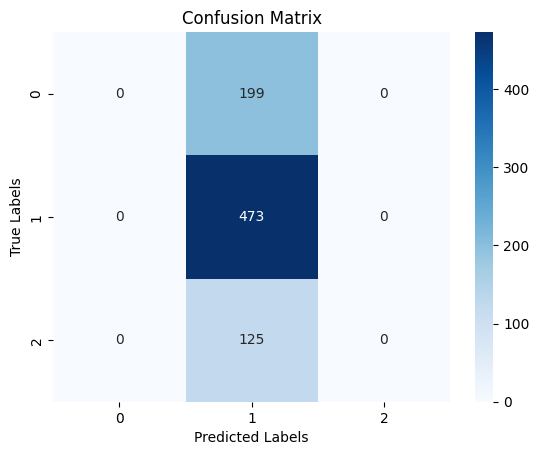

In [25]:
from sklearn.metrics import accuracy_score, confusion_matrix

accuracy = accuracy_score(all_labels, all_predictions)
print(f"Test Accuracy: {accuracy}")

import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

# ... (Your data loading and embedding extraction code)

# Reshape is not needed since all_embeddings already has the correct shape

# Perform PCA on the collected embeddings
pca = PCA(n_components=2)  # Reduce to 2 dimensions for plotting
principal_components = pca.fit_transform(all_embeddings)

# Plot PCA with age information and different colors
plt.figure(figsize=(8, 6))
scatter = plt.scatter(principal_components[:, 0], principal_components[:, 1], c=all_age_labels, cmap='viridis')
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA of wav2vec2 Embeddings with Age Information")
plt.colorbar(scatter, label="Age Label")  # Add colorbar with label
plt.show()


In [ ]:
all_embeddings = []
 all_age_labels = []
 for waveform, age_label, _ in dataloader:
     embeddings = extract_embeddings(waveform, processor, model)
     all_embeddings.extend(embeddings)
     all_age_labels.extend(age_label.tolist())

In [ ]:
import os
import torch
from torch.utils.data import Dataset, DataLoader, ConcatDataset
import torchaudio
from transformers import Wav2Vec2Processor, Wav2Vec2Model
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


# Check for CUDA availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load wav2vec2 processor and model
#processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base-960h")
#model = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base-960h").to(device)

# Function to extract wav2vec2 embeddings
def extract_embeddings(waveform, processor, model):
    with torch.no_grad():
        inputs = processor(waveform.squeeze().numpy(), sampling_rate=16000, return_tensors="pt").to(device)
        embeddings = model(**inputs).last_hidden_state.mean(dim=1).cpu().numpy()
    return embeddings

# Create dataset and dataloader
dataset = JiboDataset(root_dir='data/jibo_release/data')
dataloader = DataLoader(dataset, batch_size=32, shuffle=False)  # Set shuffle to False for consistent PCA

# Extract embeddings and age labels
all_embeddings = []
all_age_labels = []
for waveform, age_label, _ in dataloader:
    embeddings = extract_embeddings(waveform, processor, model)
    all_embeddings.extend(embeddings)
    all_age_labels.extend(age_label.tolist())

# Perform PCA
pca = PCA(n_components=2)  # Reduce to 2 dimensions for plotting
principal_components = pca.fit_transform(np.array(all_embeddings))

# Plot PCA with age information
plt.figure(figsize=(8, 6))
plt.scatter(principal_components[:, 0], principal_components[:, 1], c=all_age_labels, cmap='viridis')
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA of wav2vec2 Embeddings with Age Information")
plt.colorbar(label="Age Label")
plt.show()

In [ ]:
# 2


# i need to load the audio with wav2vec2
# what's the name of a function called in torch, for prerpcossing the data